# Vision Transformer（ViT）手写实现与推理演示

本 Notebook 分三部分：
1. 从零手写 ViT 模型，完成一次随机输入的前向推理
2. 验证图像 Patch 划分的基础参数计算
3. 调用 HuggingFace Transformers 库加载预训练 ViT，对真实图像进行分类

## 一、手写 ViT 模型定义与推理

本节从零开始实现 Vision Transformer 的核心组件，包括：
- Patch Embedding（图像块嵌入）
- Position Embedding（位置嵌入）
- CLS Token（分类标记）
- Transformer Encoder（编码器层堆叠）
- Classification Head（线性分类头）

### 1.1 导入依赖库、定义 VisionTransformer 类及运行主函数

In [18]:
from tkinter import X  # 导入 tkinter 的 X 常量（本文件中未实际使用，可忽略此导入）
import torch  # 导入 PyTorch 深度学习框架，提供张量运算与自动微分功能
import torch.nn as nn  # 导入神经网络模块，提供 Linear、Conv2d、ModuleList 等构建块
import torch.nn.functional as F  # 导入函数式接口，提供无状态的激活函数、损失函数等
import numpy as np  # 导入 NumPy 数值计算库，用于高效的多维数组操作
import torchvision.transforms as transforms  # 导入图像变换模块，用于数据预处理（本文件中未使用）
import matplotlib.pyplot as plt  # 导入 Matplotlib 绘图库，用于结果可视化（本文件中可选使用）
from torchviz import make_dot  # 导入 make_dot 函数，用于将计算图可视化为 Graphviz 图（可选）


class VisionTransformer(nn.Module):
    """
    Vision Transformer（ViT）模型

    核心思想：
        将输入图像切分为等大小的图像块（Patch），线性投影到嵌入空间，
        再拼接可学习的 CLS Token 与位置嵌入，送入标准 Transformer 编码器，
        最终用 CLS Token 的输出进行图像分类。

    继承自 nn.Module，须实现 __init__ 与 forward 两个核心方法。
    """

    def __init__(
        self,
        num_classes=10,    # 分类类别总数，默认 10（可按任务设置，如 ImageNet 为 1000）
        num_layers=12,     # Transformer 编码器的堆叠层数，默认 12（ViT-Base 标准配置）
        num_heads=8,       # 多头自注意力的头数，默认 8（hidden_dim 须能被 num_heads 整除）
        hidden_dim=768,    # 嵌入维度（Token 特征向量的长度），默认 768（ViT-Base 标准配置）
        mlp_dim=3072,      # Transformer 内 FFN 中间层维度，默认 3072（此参数由 PyTorch 内部处理）
        patch_size=16,     # 图像块边长（像素），默认 16，即将图像切成 16×16 的块
        img_size=224,      # 输入图像边长（像素），默认 224，假定输入为正方形图像
    ):
        """
        初始化 VisionTransformer 的所有子模块与可学习参数。

        参数说明见上方 __init__ 签名的行内注释。
        """
        super().__init__()  # 调用父类 nn.Module 的构造方法，完成基础初始化

        # 将超参数保存为实例属性，供 forward 及外部访问
        self.num_classes = num_classes    # 分类头输出维度
        self.num_layers = num_layers      # Transformer 层数
        self.num_heads = num_heads        # 注意力头数
        self.hidden_dim = hidden_dim      # 嵌入维度
        self.mlp_dim = mlp_dim            # FFN 中间维度（备用）
        self.patch_size = patch_size      # 图像块大小
        self.img_size = img_size          # 图像尺寸

        # ----------------------------------------------------------------
        # Patch Embedding（图像块嵌入层）
        # 利用 Conv2d 实现：令 kernel_size = stride = patch_size，
        # 卷积核不重叠地滑动，等效于将图像切成 patch_size×patch_size 的块并线性投影。
        # 输入形状: (batch_size, C,          H,                    W)
        #   - batch_size : 批量大小
        #   - C=3        : RGB 三通道
        #   - H=img_size : 图像高度（像素），本例 224
        #   - W=img_size : 图像宽度（像素），本例 224
        # 输出形状: (batch_size, D,          n_h,                  n_w)
        #   - D=hidden_dim          : 嵌入维度（每个 Patch 被投影到的特征维数），本例 768
        #   - n_h=img_size//patch_size : 垂直方向的 Patch 数量，本例 224//16=14
        #   - n_w=img_size//patch_size : 水平方向的 Patch 数量，本例 224//16=14
        # ----------------------------------------------------------------
        self.patch_embeddings = nn.Conv2d(
            in_channels=3,            # 输入通道数：RGB 三通道彩色图像
            out_channels=hidden_dim,  # 输出通道数：每个 Patch 映射到的嵌入维度
            kernel_size=patch_size,   # 卷积核大小：与 Patch 大小相同
            stride=patch_size,        # 步幅：等于 Patch 大小，保证块不重叠
        )

        # ----------------------------------------------------------------
        # Position Embedding（位置嵌入占位，可学习参数）
        # 图像共划分为 (img_size // patch_size)^2 个 Patch
        #   例：224 // 16 = 14，共 14×14 = 196 个 Patch
        # 加上 1 个 CLS Token，序列总长度 = 196 + 1 = 197
        # 位置嵌入形状: (1, S, D)
        #   - 1            : 第 0 维固定为 1，推理时通过广播扩展到 batch_size
        #   - S=num_patches+1=197 : 序列长度，等于 Patch 数(196)+CLS Token(1)
        #   - D=hidden_dim=768    : 每个位置的位置向量维度，与 Token 嵌入维度一致
        #
        # ⚠️ 注意（示意说明）：
        #   此处使用 torch.zeros 初始化，即所有位置向量均为零向量。
        #   在真正训练的 ViT 中，这些参数会通过反向传播被优化为有意义的位置编码，
        #   使模型能区分不同位置的 Token。
        #   本 demo 未经训练，position_embeddings 在整个推理过程中始终为零，
        #   等价于「没有位置信息」——此处仅在结构上展示位置嵌入应加在何处。
        # ----------------------------------------------------------------
        self.position_embeddings = nn.Parameter(
            torch.zeros(1, (img_size // patch_size) ** 2 + 1, hidden_dim)
        )

        # ----------------------------------------------------------------
        # CLS Token（分类标记，可学习参数）
        # 形状: (1, 1, D)
        #   - 1（第 0 维）: 固定为 1，forward 中通过 expand 复制到 batch_size
        #   - 1（第 1 维）: 序列长度为 1，CLS Token 只占序列中的一个位置（索引 0）
        #   - D=hidden_dim=768 : 与 Patch Token 相同的特征维度，便于后续拼接与注意力计算
        # 初始化为全零；在前向传播时扩展到每个样本，拼接到 Patch 序列头部，
        # 经 Transformer 后，其输出特征用于最终分类。
        # ----------------------------------------------------------------
        self.cls_token = nn.Parameter(torch.zeros(1, 1, hidden_dim))

        # ----------------------------------------------------------------
        # Transformer Encoder Blocks（编码器层列表）
        # nn.ModuleList 确保所有子模块的参数被正确注册到模型中
        # nn.TransformerEncoderLayer 包含：
        #   - 多头自注意力（Multi-Head Self-Attention, MSA）
        #   - 前馈网络（Feed-Forward Network, FFN）
        #   - 残差连接与 LayerNorm
        # d_model=hidden_dim: 每个 Token 的特征维度
        # nhead=num_heads:    注意力头数（hidden_dim 须能被 nhead 整除）
        # ----------------------------------------------------------------
        self.transformer_blocks = nn.ModuleList(
            [
                nn.TransformerEncoderLayer(d_model=hidden_dim, nhead=num_heads)
                for _ in range(num_layers)  # 循环创建 num_layers 个编码器层
            ]
        )

        # ----------------------------------------------------------------
        # Classification Head（分类头）
        # 线性层：将 CLS Token 的特征向量从 hidden_dim 映射到 num_classes
        # 输入形状: (batch_size, D)
        #   - batch_size   : 批量大小
        #   - D=hidden_dim=768 : CLS Token 的特征向量维度
        # 输出形状: (batch_size, K)
        #   - batch_size   : 批量大小
        #   - K=num_classes : 分类类别总数（本例 1000，对应 ImageNet-1K）
        #                    每个元素为对应类别的原始得分（logit），未经 Softmax
        # ----------------------------------------------------------------
        self.fc = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        """
        执行 ViT 的前向传播。

        参数说明：
            x (torch.Tensor): 输入图像批次
                形状: (batch_size, C, H, W)
                  - batch_size : 批量中的图像数量
                  - C=3        : RGB 三通道（Red / Green / Blue）
                  - H=img_size : 图像高度（像素），本例 224
                  - W=img_size : 图像宽度（像素），本例 224
                数据类型一般为 float32，像素值已归一化到 [0,1] 或 [-1,1]

        返回值：
            torch.Tensor: 分类 logits
                形状: (batch_size, num_classes)
                  - batch_size  : 与输入相同的批量大小
                  - num_classes : 分类任务的类别总数（本例 1000，对应 ImageNet-1K）
                每行对应一张图像在各类别上的未归一化得分
        """
        # ------ Step 1: Patch Embedding ------
        # 卷积将图像切块并线性投影到嵌入空间
        # 输入 x 形状: (batch_size, 3, 224, 224)
        #   - batch_size: 批量中的图像数量（本例推理时为 1）
        #   - 3:          RGB 三通道（Red / Green / Blue）
        #   - 224, 224:   图像高度 × 宽度（像素），与 img_size=224 一致
        # 经 Conv2d(in=3, out=768, kernel=16, stride=16) 后，输出 x 形状: (batch_size, 768, 14, 14)
        #   - 768:     嵌入维度（hidden_dim），等于 Conv2d 的 out_channels
        #   - 14, 14:  特征图高/宽 = img_size // patch_size = 224 // 16 = 14（每方向 Patch 数）
        x = self.patch_embeddings(x)
        print(f'position_embeddings后: {x.shape}')  # 输出当前张量形状，方便调试验证

        # ------ Step 2: 展平 + 转置 → 转换为序列 ------
        # flatten(2): 从第 2 维（索引 2）开始将后续所有维度展平，合并空间位置信息
        #   (batch_size, 768, 14, 14) -> (batch_size, 768, 196)
        #   - 196 = 14 × 14：将二维 Patch 网格（高×宽）展平为一维 Token 序列
        #   - 768: 每个 Patch 的嵌入特征维度（hidden_dim），作为通道维保留
        # transpose(1, 2): 交换维度 1（通道）与维度 2（序列），符合 Transformer 输入约定 (N, S, E)
        #   (batch_size, 768, 196) -> (batch_size, 196, 768)
        #   - 196: 序列长度（Token 数量），即 num_patches = (img_size // patch_size)^2
        #   - 768: 每个 Token 的特征维度（hidden_dim / embedding_dim）
        x = x.flatten(2).transpose(1, 2)

        # ------ Step 3: 拼接 CLS Token ------
        batch_size = x.shape[0]  # 取出当前批量大小（int）
        # expand: 将 cls_token 从 (1, 1, 768) 沿 batch 维度复制为 (batch_size, 1, 768)
        #   - 1（序列维度）: CLS Token 在序列中仅占一个位置（索引 0）
        #   - 768:           与 Patch Token 相同的嵌入维度，保证拼接时最后一维一致
        #   - -1 表示该维度保持原始大小不变
        cls_tokens = self.cls_token.expand(batch_size, -1, -1)
        # torch.cat 沿 dim=1（序列维度）将 CLS Token 拼接到 Patch Token 序列头部
        # (batch_size,   1, 768)  ← CLS Token，作为全局分类聚合位置
        # (batch_size, 196, 768)  ← 196 个 Patch Token（图像内容特征）
        # 拼接后 -> (batch_size, 197, 768)
        #   - 197 = 1（CLS）+ 196（Patch）：Transformer 的完整输入序列长度
        #   - 768: Token 特征维度（hidden_dim），dim=1 拼接不改变特征维
        x = torch.cat((cls_tokens, x), dim=1)

        # ------ Step 4: 加入位置嵌入（示意） ------
        # position_embeddings 形状: (1, 197, 768)，通过广播机制加到 (batch_size, 197, 768) 上
        #   - 1   → 广播至 batch_size：每个样本共用同一组位置编码（不随样本变化）
        #   - 197 → 与序列长度匹配：位置 0 对应 CLS Token，位置 1~196 对应 196 个 Patch
        #   - 768 → 位置向量维度（与 hidden_dim 相同，逐元素相加，不改变形状）
        # 加法后 x 形状不变: (batch_size, 197, 768)
        #
        # ⚠️ 注意（示意说明）：
        #   本 demo 的 position_embeddings 由 torch.zeros 初始化且未经训练，
        #   当前值为全零——加法对 x 的数值没有任何影响，Token 特征不包含任何位置信息。
        #   在正式训练的 ViT 中，该参数通过梯度下降学习到有意义的位置编码，
        #   使模型能够区分序列中不同位置的 Token（弥补 Transformer 本身无位置感的缺陷）。
        #   此行仅用于展示「位置嵌入应在此处与 Token 特征相加」的结构位置。
        x += self.position_embeddings

        # ------ Step 5: 通过 Transformer 编码器层 ------
        for transformer in self.transformer_blocks:
            # 每个 TransformerEncoderLayer 内部执行：
            #   多头自注意力（MSA）→ 残差 + LayerNorm → 前馈网络（FFN）→ 残差 + LayerNorm
            # 输入形状:  (batch_size, 197, 768)
            #   - batch_size: 批量大小
            #   - 197:        序列长度（CLS Token × 1 + Patch Token × 196）
            #   - 768:        每个 Token 的特征维度（hidden_dim / d_model）
            # 输出形状:  (batch_size, 197, 768)——序列长度与特征维度均保持不变
            #   Transformer 不改变 Token 数量或维度，只更新每个 Token 的特征表示
            x = transformer(x)
        print(f'transformer后: {x.shape}')  # 输出所有 Transformer 层处理后的形状

        # ------ Step 6: 提取 CLS Token 特征 ------
        # x[:, 0] 取序列第 0 位（CLS Token）作为全局图像表示
        # 输入 x 形状: (batch_size, 197, 768)
        #   - 197: 完整序列（CLS Token 位置 0 + 196 个 Patch Token 位置 1~196）
        # 输出 x 形状: (batch_size, 768)
        #   - 197 维的序列维度被消除，仅保留 CLS Token 位置的 768 维特征向量
        #   - 经过多层 Transformer 后，CLS Token 已通过自注意力汇聚全部 Patch 的上下文
        #   - 该向量作为整张图像的全局语义表示，送入后续分类头
        x = x[:, 0]

        # ------ Step 7: 分类头映射 ------
        # Linear(hidden_dim=768 → num_classes)，将图像全局特征投影到类别得分空间
        # 输入 x 形状: (batch_size, 768)   —— CLS Token 的全局特征向量
        # 输出 x 形状: (batch_size, num_classes)
        #   - num_classes: 分类任务的类别总数（本例 num_classes=1000，对应 ImageNet-1K）
        #   - 每个元素为对应类别的原始得分（logit），未经 Softmax 归一化
        #   - 训练时配合 nn.CrossEntropyLoss 使用（内部自动含 log-softmax）
        x = self.fc(x)
        return x  # 返回分类 logits，可配合 CrossEntropyLoss 进行训练


def generate_random_image(size=(3, 224, 224)):
    """
    生成指定形状的随机图像，用于快速测试模型推理流程。

    参数说明：
        size (tuple): 图像形状，格式为 (通道数C, 高度H, 宽度W)
                      默认 (3, 224, 224) 表示 RGB 三通道 224×224 图像

    返回值：
        np.ndarray: 值域在 [0.0, 1.0) 的随机浮点数组，dtype=float32
                    shape 与参数 size 相同
    """
    # np.random.rand(*size): 生成服从均匀分布 U[0,1) 的随机数组，*size 解包元组为位置参数
    # .astype(np.float32): 转换数据类型为 float32，与 PyTorch 默认张量类型一致
    return np.random.rand(*size).astype(np.float32)


def main():
    """
    主函数：实例化 ViT 模型，生成随机输入，执行一次完整前向推理并打印输出形状。
    """
    # 实例化 VisionTransformer 模型，num_classes=1000 对应 ImageNet 1000 类分类任务
    model = VisionTransformer(num_classes=1000)
    model.eval()  # 切换为评估模式：关闭 Dropout，BatchNorm 使用累积统计值

    # 生成一张随机 RGB 图像作为模型输入，形状: (3, 224, 224)
    random_image = generate_random_image()

    # 将 numpy 数组转为 PyTorch 张量，unsqueeze(0) 在第 0 维添加 batch 维度
    # 变化: (3, 224, 224) -> (1, 3, 224, 224)
    #   - 1:      batch_size（推理阶段单张图像，批量大小为 1）
    #   - 3:      RGB 三通道
    #   - 224, 224: 图像高度 × 宽度（像素），与模型 img_size=224 匹配
    input_tensor = torch.from_numpy(random_image).unsqueeze(0)

    # torch.no_grad(): 推理阶段禁用梯度计算，节省显存并加速前向传播
    with torch.no_grad():
        logits = model(input_tensor)  # 前向传播，返回 logits
        # logits 形状: (batch_size=1, num_classes=1000)
        #   - 1:    批量大小（单张图像）
        #   - 1000: ImageNet-1K 的类别数，每个值为对应类别的未归一化得分

    # 打印输出 logits 的张量形状，验证模型输出维度是否正确
    print('Logits:', logits.shape)

    # ---- 以下为可选的计算图可视化代码（已注释，取消注释即可使用）----
    # y = model(input_tensor)
    # dot = make_dot(y, params=dict(model.named_parameters()))  # 构建计算图对象
    # dot.format = 'png'                                          # 设置输出格式为 PNG
    # dot.render('vit_model_structure', cleanup=True, view=False)  # 渲染并保存到文件

    # ---- 以下为可选的随机图像可视化代码（已注释，取消注释即可使用）----
    # plt.imshow(random_image.transpose(1, 2, 0))  # CHW -> HWC 转置后交给 plt 显示
    # plt.title('Randomly Generated Image')
    # plt.axis('off')
    # plt.show()


# Python 标准入口守卫：直接运行本脚本时执行 main()，被其他模块 import 时不执行
if __name__ == "__main__":
    main()


position_embeddings后: torch.Size([1, 768, 14, 14])
transformer后: torch.Size([1, 197, 768])
Logits: torch.Size([1, 1000])


## 二、基础参数计算验证

对 ViT 中图像 Patch 划分相关参数进行验证性计算，确认图像在水平/垂直方向各划分的块数。

### 2.1 计算图像 Patch 划分数量

In [7]:
# 计算图像在水平（或垂直）方向上被划分的 Patch（图像块）数量
# 原理：输入图像边长为 224 像素，每个 Patch 边长为 16 像素
# 使用整除（//）确保结果为整数，无余数表示图像可被均匀划分
# 结果：224 // 16 = 14，即水平和垂直方向各有 14 个 Patch
# 总 Patch 数 = 14 × 14 = 196，加上 CLS Token 共 197 个序列位置
224 // 16  # 整除运算，返回 int 类型，结果为 14


14

## 三、使用 Transformers 库进行 ViT 推理

本节调用 HuggingFace `transformers` 库加载官方预训练 ViT-Base-Patch16-224 模型，
利用**前向钩子（Forward Hook）**截取 Transformer 编码器的中间输出，并对真实图像完成端到端的分类推理与可视化。

### 3.1 加载预训练模型并进行图像分类预测

输入图像尺寸: torch.Size([1, 3, 224, 224])
Transformer模型输出尺寸: torch.Size([1, 197, 768])
Logits尺寸: torch.Size([1, 1000])
Predicted class: Egyptian cat


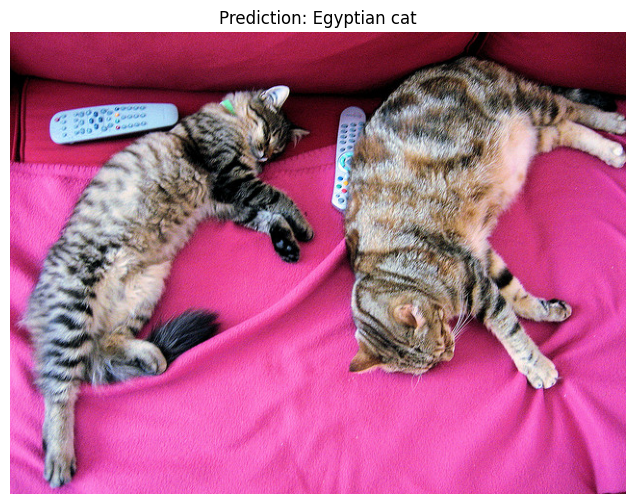

In [2]:
# 使用 HuggingFace Transformers 库加载预训练 ViT 模型，对真实图像进行分类推理
# 同时使用前向钩子（Forward Hook）截取 Transformer 编码器的中间输出，以便观察特征

# 导入 HuggingFace Transformers 库中的 ViT 相关组件：
#   ViTFeatureExtractor: 图像特征提取器，负责将 PIL 图像预处理为模型所需的张量格式
#   ViTForImageClassification: 带分类头的完整 ViT 模型，输出各类别的 logits
from transformers import ViTFeatureExtractor, ViTForImageClassification

# PIL（Pillow）库中的 Image 模块，用于图像的读取、显示和格式转换
from PIL import Image

# requests 库：发送 HTTP 请求，用于从 URL 下载图像
import requests

# PyTorch 深度学习框架，用于张量操作与推理
import torch

# Matplotlib 绘图库，用于将分类结果与图像一并可视化
import matplotlib.pyplot as plt


def predict_with_transformers_vit():
    """
    使用 HuggingFace 预训练 ViT 模型对网络图像进行分类，并可视化预测结果。

    功能流程：
        1. 加载预训练的 ViT-Base-Patch16-224 模型及对应的特征提取器
        2. 从 COCO 数据集下载一张示例图像
        3. 对图像进行预处理，得到模型输入张量
        4. 注册前向钩子，截取 Transformer 编码器的输出
        5. 执行前向推理，获得 logits 并解码预测类别
        6. 打印中间张量尺寸与最终预测结果，并可视化原图

    返回值：
        None（结果通过 print 和 plt.show() 输出）
    """
    # ---- Step 1: 加载预训练模型与特征提取器 ----
    # cache_dir: 指定模型权重文件的本地缓存目录（str 或 os.PathLike）
    #   - 首次运行时，from_pretrained 会从 HuggingFace Hub 下载权重并保存到此目录
    #   - 后续运行时，若该目录已有缓存文件则直接读取，无需重复下载
    #   - 设为 None 则使用 HuggingFace 默认缓存路径（通常为 ~/.cache/huggingface/hub）
    cache_dir = './model_cache/ViT'  # 本地缓存目录，可按需修改为自定义路径

    # ViTFeatureExtractor.from_pretrained: 从 HuggingFace Hub 下载配置与预处理参数
    # 'google/vit-base-patch16-224': 官方 ViT-Base 模型，Patch 大小 16，输入分辨率 224×224
    # cache_dir: 预处理器配置文件的本地缓存目录，与模型权重共用同一路径
    # 返回值: ViTFeatureExtractor 实例，可调用以预处理图像
    feature_extractor = ViTFeatureExtractor.from_pretrained(
        'google/vit-base-patch16-224',
        cache_dir=cache_dir,  # 指定缓存目录，避免重复下载配置文件
    )

    # ViTForImageClassification.from_pretrained: 加载在 ImageNet 上预训练的完整 ViT 模型权重
    # cache_dir: 模型权重文件（pytorch_model.bin / model.safetensors）的本地缓存目录
    # 返回值: ViTForImageClassification 实例，包含 ViT 骨干网络 + 线性分类头（1000 类）
    model = ViTForImageClassification.from_pretrained(
        'google/vit-base-patch16-224',
        cache_dir=cache_dir,  # 指定缓存目录，避免重复下载模型权重
    )

    # ---- Step 2: 下载示例图像 ----
    # COCO 2017 验证集中的一张猫的图片 URL
    url = 'http://images.cocodataset.org/val2017/000000039769.jpg'
    # requests.get(url, stream=True): 以流式方式发送 GET 请求，避免一次性加载大文件到内存
    # .raw: 获取原始字节流对象
    # Image.open(...): 用 Pillow 将字节流解码为 PIL Image 对象（RGB 格式）
    image = Image.open(requests.get(url, stream=True).raw)

    # ---- Step 3: 图像预处理 ----
    # feature_extractor(images=image, return_tensors="pt"):
    #   - images: 输入的 PIL Image 对象（或列表）
    #   - return_tensors="pt": 返回 PyTorch 张量格式
    # 内部执行：Resize → CenterCrop → Normalize（使用 ImageNet 均值/标准差）
    # 返回值: dict，键 'pixel_values' 对应形状为 (1, 3, 224, 224) 的张量
    #   - 1:      batch_size（单张图像）
    #   - 3:      RGB 三通道（经 ImageNet 均值/标准差归一化）
    #   - 224, 224: 模型输入高度 × 宽度（像素），由 ViT-Base-Patch16-224 固定
    inputs = feature_extractor(images=image, return_tensors="pt")
    print(f"输入图像尺寸: {inputs['pixel_values'].shape}")  # 验证预处理后的张量形状

    # ---- Step 4: 推理 + 前向钩子截取中间输出 ----
    with torch.no_grad():  # 禁用梯度计算：推理阶段无需反向传播，节省显存

        # 初始化容器，用于存储钩子捕获的编码器输出
        transformer_output = None

        def hook_fn(module, input, output):
            """
            前向钩子函数，在指定模块执行 forward 后自动调用。

            参数说明：
                module: 被注册钩子的模块对象（此处为 encoder）
                input:  该模块的输入（tuple），包含进入编码器的张量
                output: 该模块的输出，类型为 BaseModelOutput，含 last_hidden_state 等字段

            返回值：
                None（通过 nonlocal 将 output 保存到外部变量 transformer_output）
            """
            nonlocal transformer_output  # 声明引用外部函数作用域的变量
            transformer_output = output  # 将编码器输出保存，供推理后读取

        # register_forward_hook: 将 hook_fn 注册到 model.vit.encoder 模块
        # 每次 encoder.forward() 执行完毕后自动触发 hook_fn
        # 返回值: RemovableHook 对象，调用 .remove() 可取消注册
        hook = model.vit.encoder.register_forward_hook(hook_fn)

        # 前向传播：将预处理后的像素张量传入模型
        # **inputs 解包 dict，等价于 model(pixel_values=inputs['pixel_values'])
        # 返回值: ImageClassifierOutput，包含 logits（及可选的 hidden_states、attentions）
        outputs = model(**inputs)

        # 推理完成后立即移除钩子，避免影响后续使用该模块的其他推理调用
        hook.remove()

    # ---- Step 5: 打印编码器输出形状 ----
    # transformer_output.last_hidden_state: 编码器最后一层输出的全部 Token 特征矩阵
    # 形状: (batch_size, num_patches+1, hidden_dim) = (1, 197, 768)
    #   - 1:   batch_size（本次推理单张图像）
    #   - 197: 序列长度 = 1（CLS Token，位置 0）+ 196（Patch Token，位置 1~196）
    #          196 = 14 × 14，由 224 // 16 = 14 个 Patch 每边计算得出
    #   - 768: 每个 Token 的特征维度（hidden_dim），与 ViT-Base 标准配置一致
    print(f"Transformer模型输出尺寸: {transformer_output.last_hidden_state.shape}")

    # ---- Step 6: 解码预测结果 ----
    # outputs.logits: 分类头（Linear）输出的原始得分
    # 形状: (batch_size, num_classes) = (1, 1000)
    #   - 1:    batch_size（单张图像）
    #   - 1000: ImageNet-1K 类别数，每个值是对应类别的未归一化得分（logit）
    #           经 softmax 后可得各类别的概率分布，argmax 即为预测类别
    logits = outputs.logits
    print(f"Logits尺寸: {logits.shape}")  # 验证 logits 维度与类别数是否匹配

    # argmax(-1): 在最后一维（类别维度，dim=1，共 1000 个得分）取最大值所在索引
    #   - logits 形状 (1, 1000) → argmax(-1) 返回形状 (1,) 的张量，值为 0~999 的整数
    # .item(): 将单元素张量转换为 Python int 类型（标量），即预测的 ImageNet 类别 ID
    predicted_class_idx = logits.argmax(-1).item()

    # model.config.id2label: 字典，将整数类别 ID 映射到对应的 ImageNet 类别名称字符串
    # 返回值: str，例如 'Egyptian cat'
    predicted_class = model.config.id2label[predicted_class_idx]

    # 打印最终的分类预测类别名称
    print(f"Predicted class: {predicted_class}")

    # ---- Step 7: 可视化原图与预测结果 ----
    plt.figure(figsize=(8, 6))   # 创建宽 8 英寸、高 6 英寸的画布
    plt.imshow(image)            # 将 PIL Image 对象渲染到坐标轴上
    plt.title(f'Prediction: {predicted_class}')  # 在图上方显示预测类别名称
    plt.axis('off')              # 关闭坐标轴刻度与边框，使图像更美观
    plt.show()                   # 在当前环境（Jupyter/本地窗口）中显示图像


# 调用函数，执行完整的预训练 ViT 推理与可视化流程
predict_with_transformers_vit()
